# Problem Title - Exploration
Issue: #<issue-number>

## 1. Setup and Imports
Import pandas, matplotlib, and seaborn, then configure clean plotting defaults once.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)

## 2. Load and Inspect Data
Load dataset.csv and quickly check shape, column types, missing values, and sample rows.

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/iiitl/Neural-Networks/main/dataset.csv')
print("\Columns:", df.columns.tolist())
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_4335/1113299400.py:2: SyntaxWarning: invalid escape sequence '\C'
  print("\Columns:", df.columns.tolist())


\Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## 3. EDA (Distributions and Correlations)
Analyze feature distributions, outliers, and correlations that affect modeling decisions.

In [4]:
features = df.drop(columns=['quality', 'quality_binary'])
stats = pd.DataFrame({'min':features.min(),'max':features.max(),'mean':features.mean().round(3),'range':features.max()-features.min()})
print("=*"*25)
print("FEATURE STATISTICS — MIN, MAX, MEAN, RANGE")
print("*="*25)
print(stats)

=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
FEATURE STATISTICS — MIN, MAX, MEAN, RANGE
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
                          min        max     mean      range
fixed_acidity         3.80000   15.90000    7.215   12.10000
volatile_acidity      0.08000    1.58000    0.340    1.50000
citric_acid           0.00000    1.66000    0.319    1.66000
residual_sugar        0.60000   65.80000    5.443   65.20000
chlorides             0.00900    0.61100    0.056    0.60200
free_sulfur_dioxide   1.00000  289.00000   30.525  288.00000
total_sulfur_dioxide  6.00000  440.00000  115.745  434.00000
density               0.98711    1.03898    0.995    0.05187
pH                    2.72000    4.01000    3.219    1.29000
sulphates             0.22000    2.00000    0.531    1.78000
alcohol               8.00000   14.90000   10.492    6.90000


## 4. Visualization (Matplotlib/Seaborn)
Create at least three relevant plots and explain what each one reveals.

/tmp/ipykernel_4335/2041728232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted,x='Feature',y='Value',palette='Set2',ax=ax)


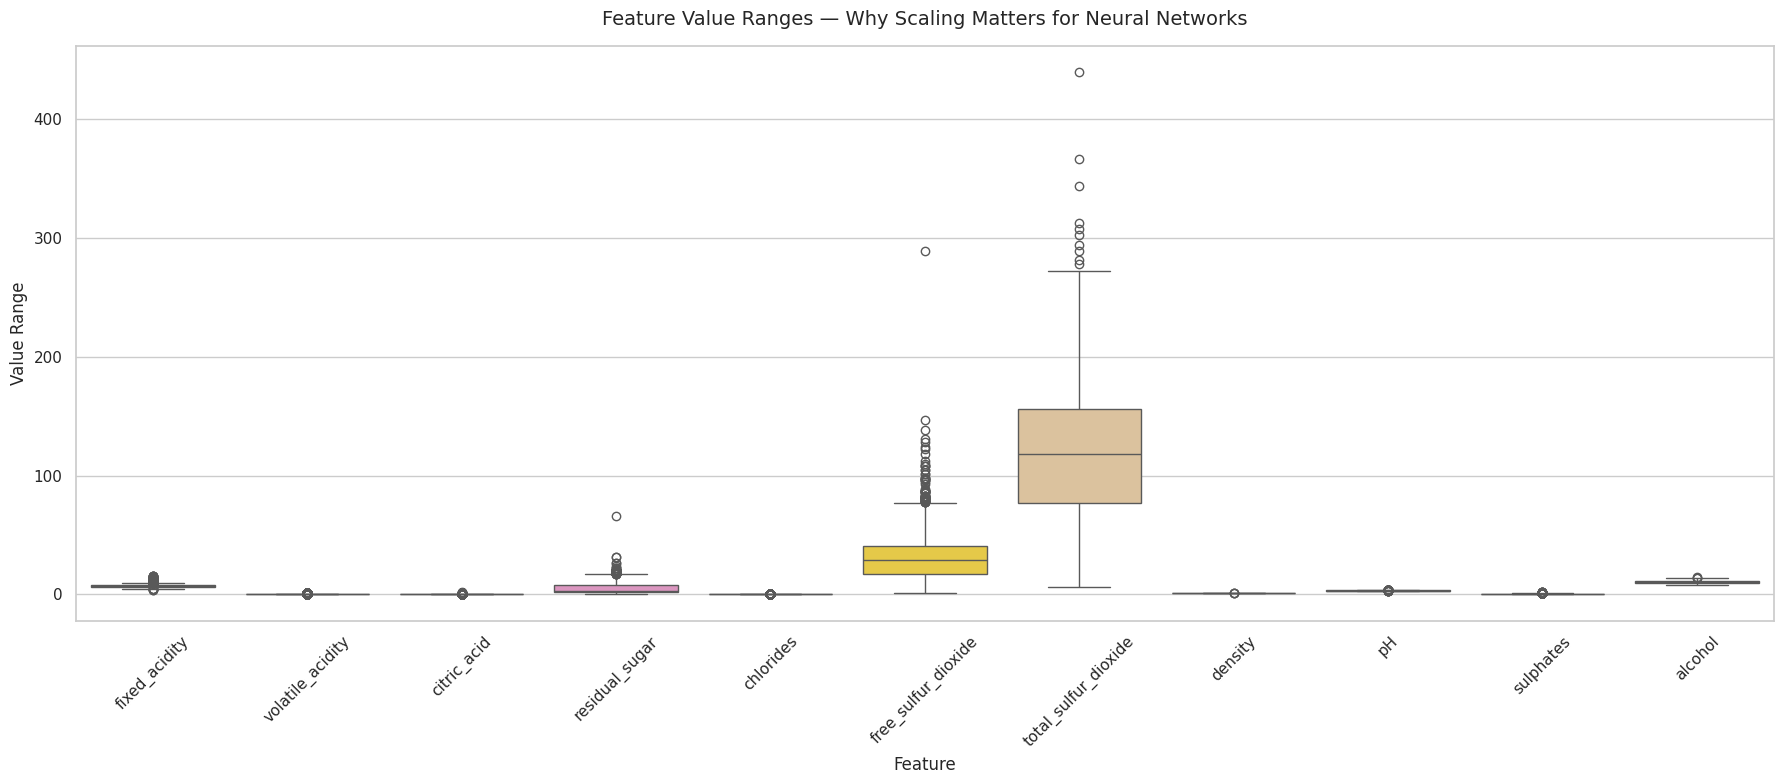

In [5]:
fig,ax=plt.subplots(figsize=(18,8))
melted = features.melt(var_name='Feature', value_name='Value')
sns.boxplot(data=melted,x='Feature',y='Value',palette='Set2',ax=ax)
ax.set_title('Feature Value Ranges — Why Scaling Matters for Neural Networks',fontsize=14, pad=15)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Value Range', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('feature_ranges_boxplot.png', bbox_inches='tight')
plt.show()


## 5. Key Observations
Write three to five concise findings linked directly to your EDA and plots.

1.**total sulfur dioxide is above all other features in scale** its box covers roughly the range of 50 to 270 and some of the outliers reach till 440

2.**free Sulphur dioxide** is second most problematic feature ,its box is around the range of 20-45 and some outliers reach around 290.

3.Citric acid,chlorides, volatile_acidity and sulphates are almost not visible in plot, their boxes are extremely small, they appear like  a flat line

4.. **The top 3 features by range are total_sulfur_dioxide (434),  free_sulfur_dioxide (288), and residual_sugar (65.2)**



## 6. Summary
Answer only these exploration-focused questions:
1. What are the top 3 dataset insights from your EDA?
*total_sulfur_dioxide is above all features with a range of 434 and mean of 115.7.
* residual_sugar is  right-skewed  to a high extent,it has  mean of 5.44 despite a max of 65.8.
*citric_acid, chlorides and volatile_acidity have ranges below 1.7, meaning they'd be completely overshadowed without scaling.

2. Which plot gave the strongest insight, and why?
The boxplot gave the strongest insight because it shows all 11 features on the same axis simultaneously.
The moment we see total_sulfur_dioxide's box  at 50–270 while
citric_acid is a flat line near zero, the scaling problem becomes very clear
3. What data issues or patterns (imbalance, skew, outliers, multicollinearity) did your visualizations reveal?
*There is a huge scale imbalance , total_sulfur_oxide has  largest mean which is 115.7 and smallest is of chloride i.e. 0.056 which is a huge ratio.